#**Experimentos da semana 2:**

Busquei demonstrar nesse notebook o passo a passo do meu aprendizado, para que também ele sirva de consulta para possíveis futuras dúvidas minhas. Por isso, a parte entregável estará no fim de cada seção:

 O entregável de embeddings está em "Criando uma função que cria embeddings e testando-a" a seção anterior refere-se ao avanço do meu aprendizado, seguindo o livro disponibilizado.

 O entregável de self-attention está nas seções: "Self-atention class", "Aplicando diversos self-atentions paralelamente, criando assim um multi-head attention" e "Criando função para testar o multi-head attention e utitizando-a variando o número de cabeças".

 O entregável de transformer está nas seções: "Implementando o Transformer Block" e "Criando e utilizando função de teste do transformer para analisar diferentes tamanhos de entrada e número de cabeças".

 Existe uma seção intitulada "Extra" se refere a implementação de um modelo gpt2 básico, acrescentei pelo fato de que com ela se encerra o capítulo 4 do livro, mas não fazia parte da checklist da semana 2.

##Preparando o ambiente utilizando o dataloader do notebook anterior

In [1]:
import torch
import tiktoken
from torch.utils.data import Dataset, DataLoader

tokenizer = tiktoken.get_encoding("gpt2")

class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

def create_dataloader_v1(txt, batch_size, max_length, stride=1,
                         shuffle=True, drop_last=True, num_workers=0):
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader

In [2]:
import urllib.request
max_length = 12

url = "https://www.gutenberg.org/files/100/100-0.txt"
txt = urllib.request.urlopen(url).read().decode('utf-8')

dataloader = create_dataloader_v1(txt ,batch_size=24, max_length=max_length, stride=max_length, shuffle=False)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

##*Embeddings*

###Criando um embedding passo a passo

In [3]:
vocab_size = 50257
output_dim = 256

tokens_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
tokens_embedding_layer.weight

Parameter containing:
tensor([[-0.2722, -0.0879,  2.0490,  ...,  1.4234,  1.2692, -0.7465],
        [-0.9289, -2.2130, -1.2928,  ...,  1.1400, -2.4972, -1.2734],
        [-0.1995,  0.8546, -0.6823,  ...,  0.8187,  1.5254, -2.5234],
        ...,
        [-0.1187, -1.1318,  0.8780,  ...,  0.4402, -0.7028,  0.9362],
        [ 0.6990,  1.1859, -0.9381,  ..., -0.8639,  0.7071, -0.7371],
        [-0.3183,  0.0709,  0.5286,  ...,  0.5079,  0.5052, -0.3525]],
       requires_grad=True)

In [4]:
print('Tokens ids:\n', inputs)
print('\nInputs shapes:\n', inputs.shape)

Tokens ids:
 tensor([[ 8162, 33303,  3963,  3336, 21965, 23680,   402,  3843,  1677, 13246,
            38,   412],
        [39453,  1802, 17202,   628,   628,   198,   464, 13248, 10933,   286,
          3977, 22197],
        [  198,   198,  1525,  3977, 22197,   628,   628,   198,   220,   220,
           220,   220],
        [  220,   220,   220,   220,   220,   220,   220,   220,   220,   220,
           220,   220],
        [  220,   220,   220, 26714,   628,   220,   220,   220,  3336,   311,
          1340, 12884],
        [   50,   198,   220,   220,   220, 11096,   447,   247,    50, 12887,
          3069, 14603],
        [12964,  5258, 12887,  3069,   198,   220,   220,   220,  3336, 29125,
            38,  1961],
        [   56,  3963,  3537, 11357,    56,  5357, 30301,  3185,  1404,  3861,
           198,   220],
        [  220,   220,  7054,  7013, 34178,  7283,   198,   220,   220,   220,
          3336,  9440],
        [ 1961,    56,  3963, 33854,    50,   198,   220,   

In [5]:
token_embeddings = tokens_embedding_layer(inputs)
token_embeddings.shape

torch.Size([24, 12, 256])

In [6]:
#max_length = 12 herdado do dataloader criado
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
pos_embedding_layer.weight

Parameter containing:
tensor([[ 5.0618e-01,  9.1879e-01, -1.5729e+00,  ..., -1.5621e+00,
          8.4727e-01,  2.0126e-02],
        [ 3.9184e-01, -1.7110e+00,  5.2701e-01,  ...,  1.3876e-03,
          6.5036e-01, -3.1410e-01],
        [ 9.5599e-01, -3.3974e-01, -1.4341e+00,  ..., -7.6043e-01,
          1.2959e-01,  9.0112e-01],
        ...,
        [-1.7622e-01, -4.0745e-01,  1.9219e-01,  ...,  9.7537e-01,
         -1.3789e+00, -1.4502e+00],
        [-3.8265e-01, -2.2050e+00,  1.7210e+00,  ..., -1.1636e-01,
         -4.6865e-01, -2.6436e-01],
        [-2.5471e+00, -6.6348e-01,  3.7136e-01,  ..., -9.8479e-01,
         -3.4807e-01,  2.3940e-01]], requires_grad=True)

In [7]:
pos_embedding_layer(torch.arange(max_length))

tensor([[ 5.0618e-01,  9.1879e-01, -1.5729e+00,  ..., -1.5621e+00,
          8.4727e-01,  2.0126e-02],
        [ 3.9184e-01, -1.7110e+00,  5.2701e-01,  ...,  1.3876e-03,
          6.5036e-01, -3.1410e-01],
        [ 9.5599e-01, -3.3974e-01, -1.4341e+00,  ..., -7.6043e-01,
          1.2959e-01,  9.0112e-01],
        ...,
        [-1.7622e-01, -4.0745e-01,  1.9219e-01,  ...,  9.7537e-01,
         -1.3789e+00, -1.4502e+00],
        [-3.8265e-01, -2.2050e+00,  1.7210e+00,  ..., -1.1636e-01,
         -4.6865e-01, -2.6436e-01],
        [-2.5471e+00, -6.6348e-01,  3.7136e-01,  ..., -9.8479e-01,
         -3.4807e-01,  2.3940e-01]], grad_fn=<EmbeddingBackward0>)

In [8]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length))
print(pos_embeddings.shape)

torch.Size([12, 256])


In [9]:
input_embeddings = token_embeddings + pos_embeddings
print('Tamanho:', input_embeddings.shape)
print('Embeddings com diferença de posição:', input_embeddings)

Tamanho: torch.Size([24, 12, 256])
Embeddings com diferença de posição: tensor([[[ 1.9869e+00,  2.4822e+00,  1.9755e-01,  ..., -1.9872e+00,
           1.0144e+00,  1.1109e+00],
         [-1.2048e+00, -4.2441e-01, -1.3558e-01,  ...,  2.7764e-01,
           4.1450e-01, -1.0268e+00],
         [-2.0694e-01,  1.6103e+00, -1.5361e+00,  ..., -1.7100e+00,
          -4.5183e-01,  5.5496e-01],
         ...,
         [-5.9186e-02, -1.6770e+00,  3.9122e-01,  ...,  1.8695e+00,
           1.3188e-01,  6.3823e-01],
         [-9.8690e-01, -2.8203e+00,  2.1091e+00,  ...,  2.7793e-01,
          -1.1127e-01,  2.8390e-01],
         [-2.1363e+00,  6.5699e-01, -6.1266e-01,  ..., -2.2300e+00,
          -5.4134e-01,  7.5441e-02]],

        [[ 1.3844e+00,  1.9616e+00, -2.3663e+00,  ..., -2.0100e-01,
           8.9430e-01,  3.5651e-01],
         [-9.0716e-01, -1.6330e+00,  3.9293e-01,  ...,  2.2834e-01,
           3.4861e-01, -5.6157e-01],
         [-1.8473e+00,  2.2312e-02, -1.8024e+00,  ..., -1.0543e+00,
    

###Criando uma função que cria embeddings e testando-a

In [10]:
import torch
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

def cria_embedings(palavras, output_dim):
  tokens = tokenizer.encode(palavras)
  input_ids = torch.tensor(tokens)

  vocab_size = 50257
  context_length = len(tokens)
  max_length = len(input_ids)

  tokens_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
  pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

  embeddings = tokens_embedding_layer(input_ids)
  positions = pos_embedding_layer(torch.arange(max_length))

  pos_embeddings = embeddings + positions

  print('Tokens:\n', tokens)
  print('\nEmbeddings sem diferença de posição:\n', embeddings)
  print('\nEmbeddings com diferença de posição:\n', pos_embeddings)


####Testando com frases pequenas e diversas dimensões, desde o padrão (256) a dimensões pequenas, permitindo uma análise mais criteriosa

Testando a palavra dog com dimensão de saída 256:

In [11]:
cria_embedings("dog", 256)

Tokens:
 [9703]

Embeddings sem diferença de posição:
 tensor([[-0.3376, -0.6933, -0.0717,  1.2371, -1.4726,  0.6925, -0.0966, -0.1530,
         -0.8035, -0.4486,  1.2379,  0.4554, -0.7822, -0.4571,  0.8265,  0.2772,
         -0.8329, -0.3314, -0.0367, -1.9521,  0.3351, -0.8250, -0.1801, -0.5453,
         -0.9860, -0.3594, -0.7623, -0.9131,  1.0192, -1.0145,  0.2675,  0.0615,
         -0.5794,  0.3752,  0.9385, -0.1411, -0.4096, -1.1134, -0.3308,  0.7451,
          0.0121,  0.0949, -1.6359, -0.0154,  0.8461,  1.2872, -0.6536,  1.3938,
         -0.8732, -2.6752,  0.6101,  1.8277,  0.3793,  1.5890,  0.7087,  0.7965,
          0.9667,  1.2542,  0.3280,  0.3872,  0.2925,  0.0152, -1.6442,  0.7371,
         -1.5123,  0.1420,  0.3226,  1.7861,  0.2329,  0.9786,  2.1747,  0.2501,
          0.3435, -0.7895,  1.1360, -0.6378, -0.1613,  0.8343, -0.2590, -0.7771,
         -0.2986,  0.2177,  1.4711, -0.1166,  0.9770,  0.0683, -0.5595,  1.1170,
         -1.0401,  1.9278,  1.0509, -1.9712,  1.1559, 

Testando a palavra dog com dimensão de saída 24:

In [12]:
cria_embedings("dog", 24)

Tokens:
 [9703]

Embeddings sem diferença de posição:
 tensor([[ 0.0655, -0.5019, -1.4725,  0.8357, -0.6005, -0.0887, -0.4320, -1.0787,
          0.0119, -0.2049, -0.6731,  0.6405,  1.2926,  0.3118,  0.9929,  0.2268,
          0.6902, -2.0492, -0.9795,  2.5158,  0.2287,  1.9274, -2.2563,  1.4379]],
       grad_fn=<EmbeddingBackward0>)

Embeddings com diferença de posição:
 tensor([[-0.1233, -0.0567, -1.6135,  0.0835,  0.5917,  0.0808, -1.0931, -2.2694,
         -0.7366,  0.4639, -0.3771,  0.8470,  1.4855,  3.0354, -0.0895, -1.1798,
          1.1676, -2.5867,  1.0446,  2.6013, -0.1428,  3.5544, -4.3198,  2.8122]],
       grad_fn=<AddBackward0>)


Testando uma frase com dimensão de saída 12:

In [13]:
cria_embedings("you are honourable!", 12)

Tokens:
 [5832, 389, 15393, 540, 0]

Embeddings sem diferença de posição:
 tensor([[ 0.5589, -0.0258, -0.5634,  1.1365, -1.3301, -0.7858, -1.0180,  1.5003,
         -0.1292,  1.6344,  0.0942, -1.4234],
        [ 0.0143, -0.8615,  0.5774, -1.4006,  0.8138,  0.4340, -0.1494,  0.3367,
          1.4662,  0.0203, -0.0250, -0.4786],
        [ 0.6949, -0.5543, -1.4871,  0.7896,  0.8018,  0.2961,  2.0773, -0.3790,
         -0.4941, -0.2134, -1.1105,  0.8353],
        [ 1.1604, -0.3853, -0.2429,  0.9521,  0.8093,  0.2205, -1.0627, -0.3691,
         -0.9357,  0.4982,  0.0896,  0.5296],
        [ 0.8381,  0.9988,  1.3564,  1.0485, -2.1046,  1.0870,  1.5003, -1.3692,
         -1.1394, -0.7208,  0.1722,  1.3027]], grad_fn=<EmbeddingBackward0>)

Embeddings com diferença de posição:
 tensor([[ 1.0365,  0.0503, -2.2117,  1.6018, -1.5596, -0.8183, -1.7339,  0.9165,
         -1.1823,  1.9241,  1.6342, -1.1605],
        [ 0.8483,  1.5500, -0.5253, -1.0548,  0.4654,  0.6657,  0.1220, -0.2015,
          2.

Testando a mesma frase com uma dimensão média para comparar a diferença

In [14]:
cria_embedings("you are honourable!", 75)

Tokens:
 [5832, 389, 15393, 540, 0]

Embeddings sem diferença de posição:
 tensor([[ 1.4178e+00, -6.3267e-02,  2.1167e+00,  1.1105e+00,  6.7877e-02,
          7.0931e-01,  1.2125e+00, -8.8906e-01, -3.9400e-01, -1.5995e-01,
          1.1008e+00, -8.0685e-01, -3.8465e-01,  4.8808e-01, -4.2325e-01,
          4.9302e-01, -9.2548e-01,  6.0254e-02, -2.0761e+00,  2.2749e+00,
         -9.9367e-01, -1.3928e+00,  1.4593e+00,  1.3854e+00, -1.9454e+00,
         -1.0035e+00,  1.4659e+00,  2.2708e+00, -2.4624e+00, -3.2008e-01,
          1.6898e-01, -1.7249e+00,  1.3176e+00,  4.3605e-01,  5.9197e-01,
         -8.7467e-01,  1.0004e-01, -2.4704e-01, -1.3538e+00,  8.1150e-02,
          2.6819e-01, -5.8048e-01,  3.7368e-01,  9.2610e-02,  2.8847e-01,
          8.5142e-01,  3.5241e-01, -1.1356e-02,  1.9881e+00,  2.9198e-01,
          1.1346e+00,  5.4434e-01, -7.9369e-01,  1.9191e+00,  2.5836e+00,
         -4.4222e-01,  8.6783e-01,  4.7394e-01, -9.2076e-01, -1.7844e+00,
          3.6089e-01,  1.7275e-01, -1

Testando a mesma frase com dimensão bem maior, para melhor análise de desempenho

In [15]:
cria_embedings("you are honourable!", 256)

Tokens:
 [5832, 389, 15393, 540, 0]

Embeddings sem diferença de posição:
 tensor([[-0.8459, -0.1569,  0.4285,  ...,  0.4553, -0.7371,  0.5035],
        [-0.5479,  0.0164,  0.9300,  ..., -0.2804, -1.9529, -0.3677],
        [ 0.6728,  0.6077,  1.7066,  ..., -2.3489,  0.5753, -0.1594],
        [-2.0848,  0.7633,  0.3692,  ..., -0.5790,  0.5127,  1.2300],
        [ 2.7553,  0.9109, -1.4253,  ...,  0.1788,  0.2368,  0.6512]],
       grad_fn=<EmbeddingBackward0>)

Embeddings com diferença de posição:
 tensor([[-0.9453,  0.8795, -1.2230,  ..., -0.7892, -1.8735,  0.2266],
        [ 0.2759, -0.0594,  0.7170,  ..., -1.8869, -3.6078, -1.8110],
        [ 1.3480, -0.2389,  2.8908,  ..., -3.1643,  1.2178,  2.1563],
        [-0.1478,  2.1467, -0.9810,  ..., -2.1966,  0.5196,  0.9987],
        [ 4.1957, -0.0213, -1.3572,  ..., -1.1864,  0.8269,  0.6317]],
       grad_fn=<AddBackward0>)


Testando outra frase com dimensão de saída 6:

In [16]:
cria_embedings("Hi, this is just a test!?-", 6)

Tokens:
 [17250, 11, 428, 318, 655, 257, 1332, 22857, 12]

Embeddings sem diferença de posição:
 tensor([[-0.9511,  2.0750,  0.3936, -1.4451, -0.3723, -0.5190],
        [-0.9766,  0.2181, -0.7527, -0.9078, -1.9930,  0.5285],
        [-1.0449, -0.3853, -1.5685,  0.3512, -0.4233, -0.3724],
        [ 0.5519, -0.1894, -0.8560,  1.9301,  0.7008,  1.8183],
        [-0.2323,  0.7629,  0.0403, -1.1685,  0.5073,  0.9435],
        [ 0.4459,  0.7947,  0.4252,  0.8605,  1.0229,  1.5202],
        [-0.0788,  0.6031,  0.4449, -0.9389,  0.2691,  0.9423],
        [-0.7163,  0.6487, -1.8461, -0.4522, -1.4815,  0.2964],
        [ 1.0165, -0.0133, -0.3357,  0.3170,  0.4240,  1.8269]],
       grad_fn=<EmbeddingBackward0>)

Embeddings com diferença de posição:
 tensor([[-1.2651,  2.1998, -0.5926,  0.5266,  1.4521, -3.3217],
        [-0.6517,  1.4233, -2.3565, -1.1143, -0.3367,  0.1650],
        [-1.7569,  2.5806,  1.3568,  1.2754, -0.1438,  1.6619],
        [ 1.5206,  0.7198, -1.8793,  2.2514,  0.3820,  2.4

Testando a palavra dog repetidas vezes na mesma frase com dimensão de saída 32, para analisar a diferença de posição:

In [17]:
cria_embedings(" dog dog dog dog", 32)

Tokens:
 [3290, 3290, 3290, 3290]

Embeddings sem diferença de posição:
 tensor([[-1.7708,  0.6360,  0.7544,  2.0473, -2.2356,  1.6272,  1.1263, -1.7846,
          0.8288, -0.4553,  2.1000, -1.3703,  1.1888,  0.7344,  1.6058, -0.0236,
         -1.9992, -2.3567,  0.5287,  1.6654, -1.3293,  1.4864,  2.7732,  1.1460,
          0.8039,  0.7606,  0.5338,  1.0402, -0.6587,  0.5948,  1.1125, -0.5011],
        [-1.7708,  0.6360,  0.7544,  2.0473, -2.2356,  1.6272,  1.1263, -1.7846,
          0.8288, -0.4553,  2.1000, -1.3703,  1.1888,  0.7344,  1.6058, -0.0236,
         -1.9992, -2.3567,  0.5287,  1.6654, -1.3293,  1.4864,  2.7732,  1.1460,
          0.8039,  0.7606,  0.5338,  1.0402, -0.6587,  0.5948,  1.1125, -0.5011],
        [-1.7708,  0.6360,  0.7544,  2.0473, -2.2356,  1.6272,  1.1263, -1.7846,
          0.8288, -0.4553,  2.1000, -1.3703,  1.1888,  0.7344,  1.6058, -0.0236,
         -1.9992, -2.3567,  0.5287,  1.6654, -1.3293,  1.4864,  2.7732,  1.1460,
          0.8039,  0.7606,  0.5338

Testando a palavra dog repetidas vezes na mesma frase com dimensão de saída 6, (para melhor analisar a diferença de posição,utilizei uma dimensão menor facilitando a comparação um a um).

Observa-se que em cada posição da frase, sem diferença de posição o embedding foi igual, já com a diferença de posição o embedding foi diferente; como esperado:

In [18]:
cria_embedings(" dog dog dog dog", 6)

Tokens:
 [3290, 3290, 3290, 3290]

Embeddings sem diferença de posição:
 tensor([[ 0.7295,  0.9273,  0.8982,  0.4351,  0.0033, -0.3534],
        [ 0.7295,  0.9273,  0.8982,  0.4351,  0.0033, -0.3534],
        [ 0.7295,  0.9273,  0.8982,  0.4351,  0.0033, -0.3534],
        [ 0.7295,  0.9273,  0.8982,  0.4351,  0.0033, -0.3534]],
       grad_fn=<EmbeddingBackward0>)

Embeddings com diferença de posição:
 tensor([[-0.0622,  1.4012, -0.7916, -0.0392, -0.6902, -1.6625],
        [ 0.3233,  0.6686,  0.4359,  0.9981, -0.3337,  1.1031],
        [ 2.3054,  0.4286,  0.5868, -0.1196,  1.2670,  0.1465],
        [ 0.1569, -0.3499,  1.2398,  0.8723, -0.1516,  0.2691]],
       grad_fn=<AddBackward0>)


##*Self-attention*

###Criando um self-attention básico do zero

####Começando de forma básica (calculando em relaçao a 1 embedding)

In [19]:
inputs = torch.tensor([[0.43, 0.15, 0.89],  #your     (xˆ1)
                       [0.55, 0.87, 0.66],  #journey  (xˆ2)
                       [0.57, 0.85, 0.64],  #starts   (xˆ3)
                       [0.22, 0.58, 0.33],  #with     (xˆ4)
                       [0.77, 0.25, 0.10],  #one      (xˆ5)
                       [0.05, 0.80, 0.55]]) #step     (xˆ6)

query = inputs[1]
query

tensor([0.5500, 0.8700, 0.6600])

Abordando várias formas de multiplicar o primeiro vetor pelo query (segundo)

In [20]:
print('Multiplicando um a um ----> ', 0.55 * 0.43 + 0.87 * 0.15 + 0.66 * 0.89)
#ou
print('Usando a função dot do torch ----> ', torch.dot(query, inputs[0]))
#ou
res = 0
for idx, element in enumerate(inputs[0]):
  res += inputs[0][idx] * query[idx]
print('Fazendo um for ----> ', res)

Multiplicando um a um ---->  0.9544
Usando a função dot do torch ---->  tensor(0.9544)
Fazendo um for ---->  tensor(0.9544)


Multiplicando todos os vetores em relação ao query

In [21]:
attn_scores_2 = inputs @ query
attn_scores_2

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])

Usando softmax para garantir que a soma dos valores do tensor seja igual a 1

In [22]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
attn_weights_2

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])

Multiplicando o tensor que obtivemos pelos vetores da matriz original (inputs) utilizando a propriedade de multiplicação de matrizes

In [23]:
context_vec_2 = attn_weights_2 @ inputs
context_vec_2

tensor([0.4419, 0.6515, 0.5683])

####Calculando em relação a cada embedding

Multiplicando a matriz de entrada pela sua transposta

In [24]:
attn_scores = inputs @ inputs.T
attn_scores

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

Utilizando softmax para garantir que a soma dos elementos de cada linha seja igual a 1

In [25]:
attn_weights = torch.softmax(attn_scores, dim=1)
attn_weights

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

Multiplicando o resultado anterior pela entrada, resultando em um self-attention super básico

In [26]:
all_context_vecs = attn_weights @ inputs
all_context_vecs

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

Organizando:

In [27]:
attn_scores = inputs @ inputs.T
attn_weights = torch.softmax(attn_scores, dim=1)
all_context_vecs = attn_weights @ inputs
all_context_vecs

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

###Aumentando o nível do self-attention

####Calculando um vetor de contexto em relação a uma camada

Criando aleatoriamente o queries, values, keys

In [28]:
d_in = inputs.shape[1]
d_out = 2

W_query = torch.nn.Parameter(torch.rand(d_in, d_out))
W_key = torch.nn.Parameter(torch.rand(d_in, d_out))
W_value = torch.nn.Parameter(torch.rand(d_in, d_out))

print('W_query:\n', W_query)
print('\nW_key:\n', W_key)
print('\nW_value:\n', W_value)

W_query:
 Parameter containing:
tensor([[0.6549, 0.0212],
        [0.8225, 0.1095],
        [0.3061, 0.8405]], requires_grad=True)

W_key:
 Parameter containing:
tensor([[0.3546, 0.7571],
        [0.4930, 0.7532],
        [0.2456, 0.3299]], requires_grad=True)

W_value:
 Parameter containing:
tensor([[0.4348, 0.1572],
        [0.1103, 0.1742],
        [0.7548, 0.2581]], requires_grad=True)


In [29]:
x_2 = inputs[1]
query_2 = x_2 @ W_query
query_2

tensor([1.2778, 0.6616], grad_fn=<SqueezeBackward4>)

In [30]:
keys = inputs @ W_key
values = inputs @ W_value

print('Keys:\n', keys)
print(keys.shape)
print('\nValues:\n', values)
print(values.shape)

Keys:
 tensor([[0.4450, 0.7321],
        [0.7860, 1.2894],
        [0.7784, 1.2829],
        [0.4450, 0.7123],
        [0.4209, 0.8042],
        [0.5472, 0.8219]], grad_fn=<MmBackward0>)
torch.Size([6, 2])

Values:
 tensor([[0.8753, 0.3234],
        [0.8333, 0.4083],
        [0.8247, 0.4028],
        [0.4087, 0.2208],
        [0.4379, 0.1904],
        [0.5252, 0.2891]], grad_fn=<MmBackward0>)
torch.Size([6, 2])


In [31]:
keys_2 = keys[1]
attn_score_22 = torch.dot(query_2, keys_2)
attn_score_22

tensor(1.8575, grad_fn=<DotBackward0>)

In [32]:
attn_scores_2 = query_2 @ keys.T
attn_scores_2

tensor([1.0530, 1.8575, 1.8434, 1.0399, 1.0699, 1.2430],
       grad_fn=<SqueezeBackward4>)

Aplicando softmax

In [33]:
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
attn_weights_2

tensor([0.1305, 0.2305, 0.2282, 0.1293, 0.1321, 0.1493],
       grad_fn=<SoftmaxBackward0>)

In [34]:
context_vec_2 = attn_weights_2 @ values
context_vec_2

tensor([0.6837, 0.3252], grad_fn=<SqueezeBackward4>)

####Novamente, agora em relação a cada camada

In [35]:
import torch.nn as nn

class SelfAttention_v2(nn.Module):

  def __init__(self, d_in, d_out, qkv_bias=False):
    super().__init__()
    self.W_query = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = torch.nn.Linear(d_in, d_out, bias=qkv_bias)

  def forward(self, x):
    queries = self.W_query(x)
    keys = self.W_key(x)
    values = self.W_value(x)

    attn_scores = queries @ keys.T
    attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)
    context_vec = attn_weights @ values

    return context_vec

sa_v2 = SelfAttention_v2(d_in, d_out)
sa_v2(inputs)

tensor([[0.2817, 0.3217],
        [0.2776, 0.3209],
        [0.2777, 0.3209],
        [0.2803, 0.3214],
        [0.2810, 0.3220],
        [0.2793, 0.3210]], grad_fn=<MmBackward0>)

###Elevando ainda mais o nível do self-attention com mascaramento

####Mask

Aproveitando a última self-attention criada:

In [36]:
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
values = sa_v2.W_value(inputs)

attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)
attn_weights

tensor([[0.1643, 0.1645, 0.1644, 0.1703, 0.1657, 0.1708],
        [0.1605, 0.1612, 0.1610, 0.1760, 0.1641, 0.1772],
        [0.1605, 0.1613, 0.1611, 0.1759, 0.1642, 0.1771],
        [0.1631, 0.1633, 0.1632, 0.1723, 0.1651, 0.1730],
        [0.1627, 0.1645, 0.1645, 0.1710, 0.1661, 0.1713],
        [0.1626, 0.1622, 0.1620, 0.1739, 0.1644, 0.1749]],
       grad_fn=<SoftmaxBackward0>)

Criando uma matriz triangular inferior

In [37]:
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


Multiplicando a matriz triangular inferior pelos pesos, resultando no mascaramento

In [38]:
masked_simple = attn_weights * mask_simple
masked_simple

tensor([[0.1643, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1605, 0.1612, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1605, 0.1613, 0.1611, 0.0000, 0.0000, 0.0000],
        [0.1631, 0.1633, 0.1632, 0.1723, 0.0000, 0.0000],
        [0.1627, 0.1645, 0.1645, 0.1710, 0.1661, 0.0000],
        [0.1626, 0.1622, 0.1620, 0.1739, 0.1644, 0.1749]],
       grad_fn=<MulBackward0>)

Aplicando softmax

In [39]:
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums

masked_simple_norm

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4989, 0.5011, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3324, 0.3340, 0.3336, 0.0000, 0.0000, 0.0000],
        [0.2464, 0.2467, 0.2465, 0.2603, 0.0000, 0.0000],
        [0.1963, 0.1985, 0.1985, 0.2063, 0.2004, 0.0000],
        [0.1626, 0.1622, 0.1620, 0.1739, 0.1644, 0.1749]],
       grad_fn=<DivBackward0>)

Utiliando de outra forma, transformando os elementos da matriz triangular inferior que deveriam ser 0 em -infinito

In [40]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal = 1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
masked

tensor([[-0.0892,    -inf,    -inf,    -inf,    -inf,    -inf],
        [-0.2283, -0.2219,    -inf,    -inf,    -inf,    -inf],
        [-0.2254, -0.2184, -0.2203,    -inf,    -inf,    -inf],
        [-0.1376, -0.1356, -0.1368, -0.0598,    -inf,    -inf],
        [-0.1097, -0.0934, -0.0940, -0.0392, -0.0799,    -inf],
        [-0.1733, -0.1771, -0.1788, -0.0790, -0.1583, -0.0703]],
       grad_fn=<MaskedFillBackward0>)

Aplicando softmax

In [41]:
attn_weights = torch.softmax(masked / d_k**0.5, dim=-1)
attn_weights

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4989, 0.5011, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3324, 0.3340, 0.3336, 0.0000, 0.0000, 0.0000],
        [0.2464, 0.2467, 0.2465, 0.2603, 0.0000, 0.0000],
        [0.1963, 0.1985, 0.1985, 0.2063, 0.2004, 0.0000],
        [0.1626, 0.1622, 0.1620, 0.1739, 0.1644, 0.1749]],
       grad_fn=<SoftmaxBackward0>)

####Dropout mask (extra)

In [42]:
layer = torch.nn.Dropout(0.5) #0,5 ou 50% de dados escondidos.
exemple = torch.ones(6,6)
exemple

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

In [43]:
layer(exemple)

tensor([[2., 0., 2., 0., 2., 0.],
        [2., 0., 2., 2., 0., 2.],
        [0., 0., 2., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [2., 2., 0., 0., 2., 0.],
        [2., 2., 2., 2., 0., 2.]])

In [44]:
layer(attn_weights)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 1.0023, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.6648, 0.0000, 0.6672, 0.0000, 0.0000, 0.0000],
        [0.4928, 0.4935, 0.4931, 0.5207, 0.0000, 0.0000],
        [0.3925, 0.0000, 0.3969, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.3240, 0.0000, 0.0000, 0.3498]],
       grad_fn=<MulBackward0>)

###Self-atention class

In [45]:
batch = torch.stack((inputs, inputs), dim=0)
batch.shape

torch.Size([2, 6, 3])

In [46]:
import torch.nn as nn

class CasualAttention(nn.Module):

  def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
    super().__init__()
    self.W_query = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = torch.nn.Linear(d_in, d_out, bias=qkv_bias)
    self.dropout = torch.nn.Dropout(dropout)
    self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape
    queries = self.W_query(x)
    keys = self.W_key(x)
    values = self.W_value(x)

    attn_scores = queries @ keys.transpose(1,2)
    attn_scores.masked_fill_(self.mask.bool() [:num_tokens, :num_tokens], -torch.inf)
    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)
    context_vec = attn_weights @ values

    return context_vec

context_length = batch.shape[1]
dropout = 0.0
ca = CasualAttention(d_in, d_out, context_length, dropout)
ca(batch)

tensor([[[ 0.1798,  0.0221],
         [-0.0740, -0.0958],
         [-0.1534, -0.1292],
         [-0.1677, -0.1359],
         [-0.1754, -0.0993],
         [-0.1913, -0.1244]],

        [[ 0.1798,  0.0221],
         [-0.0740, -0.0958],
         [-0.1534, -0.1292],
         [-0.1677, -0.1359],
         [-0.1754, -0.0993],
         [-0.1913, -0.1244]]], grad_fn=<UnsafeViewBackward0>)

###Aplicando diversos self-atentions paralelamente, criando assim um multi-head attention

####Multi-head attention básico

In [47]:
class MultiHeadAttentionWrapper(nn.Module):

  def __init__(self, d_in, d_out, context_length, dropout, num_heads=2, qkv_bias=False):
    super().__init__()
    self.heads = nn.ModuleList(
        [CasualAttention(d_in, d_out, context_length, dropout, qkv_bias=False) for _ in range(num_heads)])

  def forward(self, x):
    return torch.cat([head(x) for head in self.heads], dim=-1)

context_length = batch.shape[1]
d_in, d_out = batch.shape[-1], 2

mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, dropout=0.0, num_heads=2)
mha(batch)

tensor([[[-0.4780,  0.1637,  0.5415,  0.0799],
         [-0.4787,  0.1310,  0.7173, -0.0496],
         [-0.4757,  0.1238,  0.7734, -0.0955],
         [-0.4195,  0.0971,  0.6986, -0.0937],
         [-0.3730,  0.1204,  0.6736, -0.1389],
         [-0.3693,  0.0918,  0.6476, -0.1151]],

        [[-0.4780,  0.1637,  0.5415,  0.0799],
         [-0.4787,  0.1310,  0.7173, -0.0496],
         [-0.4757,  0.1238,  0.7734, -0.0955],
         [-0.4195,  0.0971,  0.6986, -0.0937],
         [-0.3730,  0.1204,  0.6736, -0.1389],
         [-0.3693,  0.0918,  0.6476, -0.1151]]], grad_fn=<CatBackward0>)

####Multi-head attention with weight splits

In [48]:
class MultiHeadAttention(nn.Module):

  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert(d_out % num_heads == 0), \
      "d_out deve ser divisível por num_heads"

    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out // num_heads

    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.out_proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape

    keys = self.W_key(x)
    queries = self.W_query(x)
    values = self.W_value(x)

    keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
    queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)
    values = values.view(b, num_tokens, self.num_heads, self.head_dim)

    keys = keys.transpose(1,2)
    queries = queries.transpose(1,2)
    values = values.transpose(1,2)

    attn_scores = queries @ keys.transpose(2,3)

    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

    attn_scores.masked_fill_(mask_bool, -torch.inf)

    attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    context_vec = (attn_weights @ values).transpose(1,2)
    context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
    context_vec = self.out_proj(context_vec)

    return context_vec

batch_size, context_length, d_in = batch.shape
d_out = 4
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)

context_vecs = mha(batch)

print(context_vecs)
print('Context_vecs.shape:', context_vecs.shape)

tensor([[[ 0.0235, -0.3546, -0.3391,  0.3091],
         [ 0.0829, -0.3970, -0.4398,  0.3478],
         [ 0.1041, -0.4123, -0.4717,  0.3624],
         [ 0.0606, -0.3744, -0.4707,  0.3352],
         [ 0.0395, -0.3508, -0.4263,  0.3400],
         [ 0.0256, -0.3403, -0.4516,  0.3237]],

        [[ 0.0235, -0.3546, -0.3391,  0.3091],
         [ 0.0829, -0.3970, -0.4398,  0.3478],
         [ 0.1041, -0.4123, -0.4717,  0.3624],
         [ 0.0606, -0.3744, -0.4707,  0.3352],
         [ 0.0395, -0.3508, -0.4263,  0.3400],
         [ 0.0256, -0.3403, -0.4516,  0.3237]]], grad_fn=<ViewBackward0>)
Context_vecs.shape: torch.Size([2, 6, 4])


###Criando função para testar o multi-head attention e utitizando-a variando o número de cabeças:

In [49]:
def testa_mha(batch, d_out, num_heads):
  batch_size, context_length, d_in = batch.shape
  mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads)
  context = mha(batch)
  print('Shape:', context.shape)
  print('\n', context)

Variando o número de heads, a dimenção da saída e o shape do batch

In [50]:
batch = torch.randn(32, 24, 14)
testa_mha(batch, 8, 4)

Shape: torch.Size([32, 24, 8])

 tensor([[[ 0.1483, -0.3361,  0.2678,  ...,  0.4212, -0.0041,  0.1501],
         [ 0.1086, -0.4247,  0.2727,  ...,  0.3900, -0.1345,  0.2911],
         [ 0.1174, -0.4374,  0.2271,  ...,  0.3510, -0.0715,  0.2260],
         ...,
         [ 0.1499, -0.2193,  0.0062,  ...,  0.1428,  0.1655, -0.0131],
         [ 0.0986, -0.2213, -0.0470,  ...,  0.1920,  0.1174,  0.0153],
         [ 0.0698, -0.2143, -0.0785,  ...,  0.2270,  0.1197,  0.0174]],

        [[ 0.1640, -0.4752,  0.1895,  ...,  0.4032,  0.1197,  0.0637],
         [ 0.2824, -0.4508,  0.0920,  ..., -0.0176,  0.3023, -0.2155],
         [ 0.1410, -0.3397, -0.1085,  ..., -0.0673,  0.2848, -0.2487],
         ...,
         [ 0.1471, -0.1912, -0.2084,  ..., -0.0614,  0.2350, -0.2368],
         [ 0.1386, -0.1115, -0.1947,  ..., -0.0952,  0.3016, -0.2055],
         [ 0.1465, -0.1830, -0.1877,  ..., -0.0151,  0.2601, -0.2401]],

        [[ 0.3551, -0.0152, -0.2139,  ...,  0.2363,  0.4829, -0.1885],
         [-0

In [51]:
batch = torch.randn(6, 24, 14)
testa_mha(batch, 8, 4)

Shape: torch.Size([6, 24, 8])

 tensor([[[ 0.2371,  0.2903, -0.0656,  ..., -0.1379,  0.3169, -1.0540],
         [-0.0094,  0.1178, -0.1233,  ..., -0.2381,  0.2117, -0.6117],
         [-0.2963,  0.0784, -0.2849,  ..., -0.2724,  0.0719, -0.5222],
         ...,
         [-0.3119,  0.2086, -0.2761,  ..., -0.1209, -0.0847, -0.3491],
         [-0.3362,  0.1546, -0.2227,  ..., -0.1384, -0.0430, -0.3306],
         [-0.3168,  0.2047, -0.2856,  ..., -0.1416, -0.0992, -0.3414]],

        [[-0.4326,  0.4011,  0.1588,  ...,  0.2949, -0.2016,  0.3896],
         [-0.3315,  0.5824, -0.1010,  ...,  0.2697, -0.3033, -0.0996],
         [-0.2944,  0.4533, -0.1971,  ...,  0.0929, -0.3107, -0.1494],
         ...,
         [-0.2825,  0.1827, -0.1805,  ..., -0.1148, -0.0340, -0.2658],
         [-0.3211,  0.2191, -0.2251,  ..., -0.1053, -0.0569, -0.3111],
         [-0.3858,  0.2346, -0.2430,  ..., -0.0782, -0.0693, -0.3183]],

        [[ 0.0630,  0.3420, -0.1628,  ...,  0.0474, -0.1025, -0.4528],
         [-0.

In [52]:
batch = torch.randn(6, 4, 3)
print(batch)
testa_mha(batch, 6, 2)

tensor([[[ 0.4859,  1.0349,  0.4472],
         [-1.0863, -0.4586,  0.2572],
         [-0.1123,  0.6858,  0.1854],
         [ 0.7076,  0.8218,  1.6685]],

        [[-0.2469, -0.6474,  1.8202],
         [-2.8146,  1.6763, -1.7517],
         [ 1.5322, -0.0696,  1.9849],
         [-0.0309, -0.3449, -0.2298]],

        [[-0.1384,  0.3831,  0.2365],
         [-1.1119,  0.5991,  0.5951],
         [ 0.1103,  0.2791,  3.4340],
         [ 0.2974, -0.3449, -0.5905]],

        [[-1.1734, -0.5264, -0.4568],
         [ 0.7746,  1.7529,  0.2725],
         [ 1.0646,  0.2583,  0.8431],
         [-0.0227, -0.5403,  0.7809]],

        [[ 0.7377, -0.5378, -1.4884],
         [ 0.1534,  0.2603,  0.7435],
         [-0.1023,  0.1380, -1.0262],
         [ 0.1672,  0.4715, -0.1239]],

        [[-0.6954,  1.6072,  1.2822],
         [ 0.6326,  0.0703,  0.8538],
         [ 1.2851,  1.6959,  0.9019],
         [ 2.1199, -1.8738, -0.2923]]])
Shape: torch.Size([6, 4, 6])

 tensor([[[ 0.0811, -0.3201, -0.3375,  0.1029,

In [53]:
batch = torch.randn(4, 3, 3)
testa_mha(batch, 4, 2)

Shape: torch.Size([4, 3, 4])

 tensor([[[ 0.1883, -0.3057,  0.5646, -0.5436],
         [ 0.2530, -0.1255,  0.5208, -0.5544],
         [ 0.2609, -0.3699,  0.5417, -0.7299]],

        [[ 0.9336,  0.8791,  0.0719, -0.6808],
         [ 0.7329,  0.4593,  0.1876, -0.5355],
         [ 0.5946,  0.3330,  0.2549, -0.5528]],

        [[ 0.2543, -0.1024,  0.4012,  0.0631],
         [ 0.5928, -0.0385,  0.2598, -0.2229],
         [ 0.4207,  0.5503,  0.3300, -0.2410]],

        [[ 1.0776,  1.7010, -0.2224,  0.4122],
         [ 0.7770,  0.5258,  0.1187, -0.1740],
         [ 0.6112,  0.5726,  0.1672, -0.0315]]], grad_fn=<ViewBackward0>)


In [54]:
batch = torch.randn(4, 72, 34)
testa_mha(batch, 96, 8)

Shape: torch.Size([4, 72, 96])

 tensor([[[-9.9190e-03,  1.6001e-01, -5.2090e-02,  ..., -1.0784e-01,
          -2.4781e-02,  4.1148e-01],
         [-2.7359e-01,  4.5776e-01, -3.9165e-02,  ..., -2.9185e-01,
          -1.1419e-01,  2.5154e-01],
         [-4.3063e-02,  2.5604e-01, -1.0821e-01,  ..., -1.9822e-01,
          -2.9884e-01,  2.5445e-01],
         ...,
         [-1.4989e-02, -8.5041e-02, -1.1991e-02,  ..., -3.6459e-02,
           5.9930e-02, -1.4214e-02],
         [-3.6476e-02, -8.3649e-02, -4.1900e-02,  ..., -6.2516e-02,
           5.0124e-02, -4.3008e-02],
         [-7.4508e-02, -7.9481e-02, -3.6039e-02,  ..., -6.0167e-02,
           8.2694e-02, -5.7803e-02]],

        [[-3.3642e-01,  8.7452e-02,  3.0130e-01,  ..., -5.1226e-02,
           2.7287e-01, -2.3551e-01],
         [-1.9097e-01, -4.1784e-03,  1.1991e-01,  ..., -2.5976e-01,
           1.7791e-01, -1.3887e-01],
         [-2.6535e-01, -1.2786e-02,  3.6305e-02,  ..., -2.3198e-01,
           3.0540e-01, -8.1308e-02],
      

##Transformer Block



###Arquitetura de uma LLM:

In [55]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers (vezes que o transformador é executado)
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

Criando um protótipo de modelo que será utilizado como base

In [56]:
class DummyGPTModel(nn.Module):

  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])
    self.trf_blocks = nn.Sequential(*[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])
    self.final_norm = DummyLayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

  def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits


class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    def forward(self, x):
        return x


class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x

In [57]:
batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)
print(batch.shape)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
torch.Size([2, 4])


Testando o protótipo

In [58]:
model = DummyGPTModel(GPT_CONFIG_124M)

logits = model(batch)
print('Output shape:', logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.8697, -0.9290, -0.9632,  ..., -0.4582, -1.4630,  0.4032],
         [-0.7411,  0.8036,  0.1167,  ...,  1.6970, -0.4175,  1.3764],
         [ 0.1150,  0.6953, -0.4484,  ..., -0.3452, -2.2899,  0.5761],
         [ 1.2702, -0.3759, -0.9625,  ..., -0.2357,  0.6635,  0.8013]],

        [[-0.7953, -1.1441, -0.5233,  ..., -0.8073, -1.0352, -0.2009],
         [-1.2705, -0.0988,  0.1047,  ...,  0.2226,  0.9127,  0.7233],
         [ 0.3063, -0.9122,  1.1379,  ...,  1.0278, -0.6053, -0.0746],
         [-0.1718,  0.3977, -0.1929,  ...,  0.1316,  0.1810,  0.0037]]],
       grad_fn=<UnsafeViewBackward0>)


###Normalizing activations

In [59]:
batch_example = torch.randn(2,5)
batch_example

tensor([[ 1.2241, -1.1776,  0.8487, -0.5651, -0.0144],
        [-0.4047,  0.8222, -0.1799,  0.2692,  0.3943]])

In [60]:
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
out = layer(batch_example)
out

tensor([[0.0000, 0.6593, 0.0000, 0.9672, 0.3627, 0.2075],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.1378, 0.0000]],
       grad_fn=<ReluBackward0>)

Calcula a média da linha 1 e da linha 2

In [61]:
mean = out.mean(dim=-1, keepdim=True)
mean

tensor([[0.3661],
        [0.0230]], grad_fn=<MeanBackward1>)

In [62]:
var = out.var(dim=-1, keepdim=True)
var

tensor([[0.1481],
        [0.0032]], grad_fn=<VarBackward0>)

In [63]:
(out-mean).mean(dim=-1)

tensor([9.9341e-09, 0.0000e+00], grad_fn=<MeanBackward1>)

In [64]:
torch.set_printoptions(sci_mode=False)
normed = ((out - mean) / torch.sqrt(var))
print('Média:\n', normed.mean(dim=-1, keepdim=True))
print('Variação:\n', normed.var(dim=-1, keepdim=True))

Média:
 tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Variação:
 tensor([[1.],
        [1.]], grad_fn=<VarBackward0>)


In [65]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [66]:
ln = LayerNorm(6)
outputs_normed = ln(out)
print(outputs_normed)
print('Média:\n', outputs_normed.mean(dim=-1, keepdim=True))
print('Variação:\n', outputs_normed.var(dim=-1, keepdim=True, unbiased=False))

tensor([[-1.0421,  0.8345, -1.0421,  1.7110, -0.0098, -0.4514],
        [-0.4464, -0.4464, -0.4464, -0.4464,  2.2318, -0.4464]],
       grad_fn=<AddBackward0>)
Média:
 tensor([[ 0.0000],
        [-0.0000]], grad_fn=<MeanBackward1>)
Variação:
 tensor([[0.9999],
        [0.9962]], grad_fn=<VarBackward0>)


###Feed forward network com GELU

Criando GELU

In [67]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

Comparando ReLU com GELU

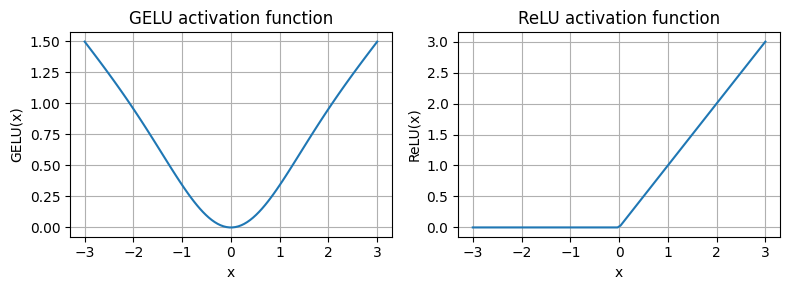

In [68]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8,3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ['GELU', 'ReLU']), 1):
  plt.subplot(1,2,i)
  plt.plot(x,y)
  plt.title(f'{label} activation function')
  plt.xlabel('x')
  plt.ylabel(f'{label}(x)')
  plt.grid(True)

plt.tight_layout()
plt.show()

Função de criação de uma mini rede neural:

In [69]:
class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(cfg['emb_dim'], 4 * cfg['emb_dim']),
        GELU(),
        nn.Linear(4 * cfg['emb_dim'], cfg['emb_dim'])
    )

  def forward(self, x):
    return self.layers(x)

In [70]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)
ffn(x).shape

torch.Size([2, 3, 768])

Verificando os pesos criados na camada linear

In [71]:
print(ffn.layers, '\n')
print(ffn.layers[0].weight)

Sequential(
  (0): Linear(in_features=768, out_features=3072, bias=True)
  (1): GELU()
  (2): Linear(in_features=3072, out_features=768, bias=True)
) 

Parameter containing:
tensor([[-0.0213, -0.0160, -0.0322,  ..., -0.0236, -0.0289,  0.0105],
        [-0.0303,  0.0034, -0.0017,  ...,  0.0007,  0.0266, -0.0047],
        [ 0.0036,  0.0094,  0.0145,  ..., -0.0032,  0.0334, -0.0187],
        ...,
        [ 0.0278, -0.0133,  0.0060,  ...,  0.0023, -0.0251, -0.0229],
        [-0.0344, -0.0045, -0.0315,  ..., -0.0155,  0.0285, -0.0131],
        [ 0.0099, -0.0145, -0.0128,  ...,  0.0261, -0.0162, -0.0281]],
       requires_grad=True)


###Adicionando shortcut connections

In [72]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])
    loss = nn.MSELoss()
    loss = loss(output, target)
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")


Analisando o aumento dos gradientes quando se usa o atalho

In [73]:
layer_sizes = [3,3,3,3,3,1]
sample_input = torch.tensor([[1.,0.,-1.]])

model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 3.154726755383308e-07
layers.1.0.weight has gradient mean of 2.9040347726549953e-07
layers.2.0.weight has gradient mean of 1.4562560863851104e-06
layers.3.0.weight has gradient mean of 1.585555583005771e-05
layers.4.0.weight has gradient mean of 0.00027284224051982164


In [74]:
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.0009245087276212871
layers.1.0.weight has gradient mean of 2.1336025383789092e-05
layers.2.0.weight has gradient mean of 0.0011508105089887977
layers.3.0.weight has gradient mean of 0.0010820830939337611
layers.4.0.weight has gradient mean of 0.00951742846518755


###Implementando o Transformer Block

In [75]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
     super().__init__()
     self.att = MultiHeadAttention(
         d_in = cfg["emb_dim"],
         d_out = cfg["emb_dim"],
         context_length = cfg['context_length'],
         num_heads = cfg['n_heads'],
         dropout = cfg['drop_rate'],
         qkv_bias= cfg['qkv_bias'])
     self.ff = FeedForward(cfg)
     self.norm1 = LayerNorm(cfg['emb_dim'])
     self.norm2 = LayerNorm(cfg['emb_dim'])
     self.drop_shortcut = nn.Dropout(cfg['drop_rate'])

  def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

Testando-o

In [76]:
x = torch.rand(2, 4, 768)  # Shape: [batch_size, num_tokens, emb_dim]
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


###Criando e utilizando função de teste do transformer para analisar diferentes tamanhos de entrada e número de cabeças:

In [77]:
def analisa_transformer(emb, heads, x):
  config = {  "vocab_size": 50257,
             "context_length": 1024,
             "emb_dim": emb,
              "n_heads": heads,
             "n_layers": 12,
              "drop_rate": 0.1,
              "qkv_bias": False}
  block = TransformerBlock(config)
  output = block(x)
  print("Input shape:", x.shape)
  print("Output shape:", output.shape)

Analisando para o tamanho de entrada 768 e 12 cabeças:

In [78]:
analisa_transformer(768, 12, torch.rand(3,4,768))

Input shape: torch.Size([3, 4, 768])
Output shape: torch.Size([3, 4, 768])


Analisando para o tamanho de entrada 36 e 6 cabeças:

In [79]:
analisa_transformer(36, 6, torch.rand(3,4,36))

Input shape: torch.Size([3, 4, 36])
Output shape: torch.Size([3, 4, 36])


Analisando para o tamanho de entrada 39 e 3 cabeças:

In [80]:
analisa_transformer(39, 3, torch.rand(3,4,39))

Input shape: torch.Size([3, 4, 39])
Output shape: torch.Size([3, 4, 39])


Analisando para o tamanho de entrada 1040 e 104 cabeças:

In [81]:
analisa_transformer(1040, 104, torch.rand(3,4,1040))

Input shape: torch.Size([3, 4, 1040])
Output shape: torch.Size([3, 4, 1040])


#Extra:

##Implementando GPT model

In [82]:
class GPTModel(nn.Module):

  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

  def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [83]:
batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)
print(batch.shape)
print('Parâmetros do batch:', batch.numel()) #Função que calcula a quantidade de valores do vetor

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
torch.Size([2, 4])
Parâmetros do batch: 8


In [84]:
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print(out.shape)

torch.Size([2, 4, 50257])


In [85]:
total_params = sum(p.numel() for p in model.parameters())
print(total_params)

163009536


Calculamos acima o número total de parâmetros do nosso modelo, mas no GPT2 há compartilhamento de pessos, o que não adotamos aqui, logo, contamos duas vezes a matriz de pesos enquanto que no GPT2 só se conta uma vez, para termos o resultado do GPT2, subtrairemos da nossa soma a quantidade de elementos de uma das matrizes de pesos.

In [86]:
total_params_gpt2 = total_params - model.out_head.weight.numel()
total_params_gpt2

124412160

Testando para outras configurações (exercício proposto pelo autor do livro)

Observei que o tempo de execução cresce consideravelmente, provando que o modelo se torna mais "pesado"

In [87]:
GPT_CONFIG_345M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 1024,         # Embedding dimension
    "n_heads": 16,          # Number of attention heads
    "n_layers": 24,         # Number of layers (vezes que o transformador é executado)
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}
model_test = GPTModel(GPT_CONFIG_345M)
out = model_test(batch)
params = sum(p.numel() for p in model_test.parameters())
params_gpt = params - model_test.out_head.weight.numel()
params_gpt

354749440

In [88]:
GPT_CONFIG_762M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 1280,         # Embedding dimension
    "n_heads": 20,          # Number of attention heads
    "n_layers": 36,         # Number of layers (vezes que o transformador é executado)
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}
model_test = GPTModel(GPT_CONFIG_762M)
out = model_test(batch)
params = sum(p.numel() for p in model_test.parameters())
params_gpt = params - model_test.out_head.weight.numel()
params_gpt

773891840

In [89]:
GPT_CONFIG_1542M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 1600,         # Embedding dimension
    "n_heads": 25,          # Number of attention heads
    "n_layers": 48,         # Number of layers (vezes que o transformador é executado)
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}
model_test = GPTModel(GPT_CONFIG_1542M)
out = model_test(batch)
params = sum(p.numel() for p in model_test.parameters())
params_gpt = params - model_test.out_head.weight.numel()
params_gpt

1557380800

##Usando o modelo criado para gerar texto

In [90]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
  for _ in range(max_new_tokens):
    idx_cond = idx[:, -context_size:] #truncando a entrada para um tamanho que o modelo suporte
    with torch.no_grad(): #não calculamos o gradiente porque não estamos treinando ainda
      logits = model(idx_cond)
    logits = logits[:, -1, :]

    probas = torch.softmax(logits, dim=-1)
    idx_next = torch.argmax(probas, dim=-1, keepdim=True) #retorna o índice da posição em que se encontra o maior elemento
    idx = torch.cat((idx, idx_next), dim=1) #concatena tensores, dim=0 empilha embaixo (linhas), dim=1 emplinha ao lado (colunas)

  return idx

In [91]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [92]:
out = generate_text_simple(model=model, idx=encoded_tensor, max_new_tokens=6, context_size=GPT_CONFIG_124M['context_length'])
out

tensor([[15496,    11,   314,   716, 39606, 32389, 14795, 25518, 21523, 15499]])

In [93]:
out = out.squeeze(0) #elimina uma dimensão do tensor para posteriormente transforma-lo numa lista
out = out.tolist() #transforma em lista para poder ser usado no decoder
tokenizer.decode(out)

'Hello, I am Cookie Firearmsuv withdrew Evan triumph'